## Configure Defaults

In [2]:
import os

MODELS_DIR = 'models/'
if not os.path.exists(MODELS_DIR):
    os.mkdir(MODELS_DIR)

MODEL_TF = MODELS_DIR + 'model'
MODEL_NO_QUANT_TFLITE = MODELS_DIR + 'model_no_quant.tflite'
MODEL_QUANT_TFLITE = MODELS_DIR + 'model_quant.tflite'
MODEL_TFLITE_MICRO = MODELS_DIR + 'model.cc'

## Setup Environment

Install Dependencies

In [7]:
! pip install tensorflow==2.4.0

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try 'pacman -S
    python-xyz', where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Arch-packaged Python package,
    create a virtual environment using 'python -m venv path/to/venv'.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip.
    
    If you wish to install a non-Arch packaged Python application,
    it may be easiest to use 'pipx install xyz', which will manage a
    virtual environment for you. Make sure you have python-pipx
    installed via pacman.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detailed specification.


Import Dependencies

In [8]:
# Tensorflow is an open-source ML lib
import tensorflow as tf

# Keras is Tensorflow's high-level API for deep learning
from tensorflow import keras

# Numpy is a math lib
import numpy as np

# Panda is a data manipulation lib
import pandas as pd

# Matplotlib is a graphing lib
import matplotlib.pyplot as plt

# Math is Python's math lib
import math

# Set seed for experimental reproducibility
seed = 1
np.random.seed(seed)
tf.random.set_seed(seed)

I0000 00:00:1782303558.368176   75367 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1782303558.418222   75367 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1782303560.478057   75367 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## Dataset

## 1. Generate Data

The following code generates a set of random x values, calculate their sine values, and displays the result on a graph.

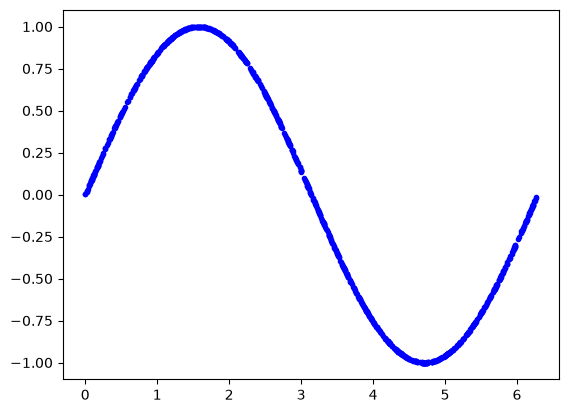

In [9]:
# How many data points we have
SAMPLES = 1000

# Generate uniformly distributed set of random numbers ranging from 0-2π (a complete sine oscillation), the numbers are 32-bit floats.
x_values = np.random.uniform(low = 0, high = 2*math.pi, size=SAMPLES).astype(np.float32)

# Shuffle the values to ensure that they are not in order
# deep learning training depends on data being in random order, otherwise it will be less accurate
np.random.shuffle(x_values)

# Calculate the corresponding y-values
y_values = np.sin(x_values).astype(np.float32)

# Plot the values ('b.' tells the library to print in blue (b) dots (.))
plt.plot(x_values, y_values, 'b.')
plt.show()

## 2. Add Noise

The data fits the sine way perfectly, which does not represent real world data.

Machine learning models are good at extracting meaning from messy data, to simulate this we add some noise to the data.

In the following cell, we'll add some random noise then draw a graph of the new data as compared to the old.

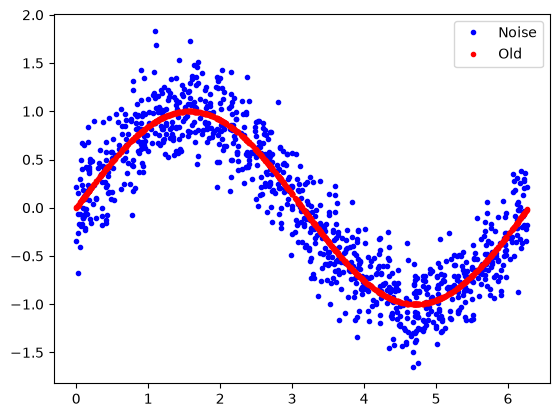

In [18]:
# Save old y_values
old_y_values = np.sin(x_values).astype(np.float32)

# Add ranodom y-offset
y_values += 0.1 * np.random.randn(*y_values.shape)

# Plot the data
plt.plot(x_values, y_values, 'b.', label='Noise')
plt.plot(x_values, old_y_values, 'r.', label='Old')
plt.legend()
plt.show()

## 3. Split The Data

We now have noisy data that approximates real world data. We will use this to train our model.

In order to evaluate accuracy we need to compare its predictions against real data and check how well they match. This will be done during training (called validation) and after training (referred to as testing). The data needs to be fresh.

The typical split is 60% for training, 20% for validation and 20% for testing.

We will use NumPy's ```split()``` method for this. It takes the array we want to split as well as an array of indices where we want the split to happen. The method returns a list of arrays for each split chunk.

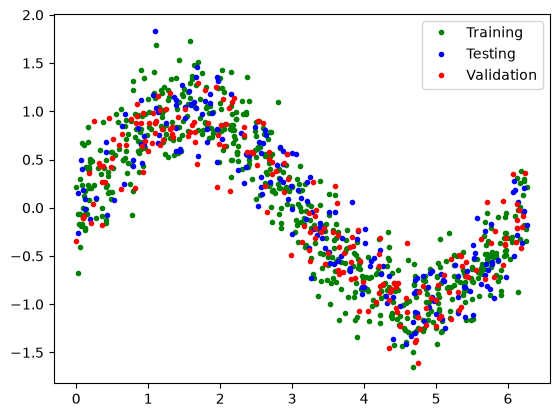

In [19]:
# 60% of the data will be used for training and 20% for testing. The remaining 20% will be used for validation.
TRAIN_SPLIT = int(0.6*SAMPLES)
TEST_SPLIT = int(0.2*SAMPLES + TRAIN_SPLIT)

# The data will be divided into three chunks as we provide 2 indices.
x_train, x_test, x_validate = np.split(x_values, [TRAIN_SPLIT, TEST_SPLIT])
y_train, y_test, y_validate = np.split(y_values, [TRAIN_SPLIT, TEST_SPLIT])

# Plot each partition in different colors:
plt.plot(x_train, y_train, 'g.', label='Training')
plt.plot(x_test, y_test, 'b.', label='Testing')
plt.plot(x_validate, y_validate, 'r.', label='Validation')
plt.legend()
plt.show()

## Training

## 1. Design The Model

We will build a model that takes a numerical value `x` as input and gives a numerical value `y` as output (in this case the sine of `x`). This type of problem is called a _regression_. Regression models can also be used to predict a person's running speed based on data from an accelorometer for example.

For this problem we will start by creating a simple neural network consisting of 2 layers. The first layer will take an input `x` and runs it through 8 neurons. The neuron will then become _activated_ to a certain degree. The amount of activation for each neuron is based on its _weight_ and _bias_ values, learned during training, as well as its _activation function_. The activation is calculated as ```activation = activation_function((input * weight) + bias)```. The activation function we will use is called _rectified linear unit_, or ReLU for short. ReLU is defined as ```ReLU(x) = max(0, x)```. The reason we use an activation function is because without it the network could only model linear relationships where the ratio between `x` and `y` always stays the same. This would not work for this example as a sine wave is nonlinear.

The following cell defines the simple network model using Keras, TensorFlow's high-level API for creating deep-learning networks. The architecture that we will use will be `Sequential` meaning each layer will be stacked on top of the next. The first layer will have 8 neurons and 1 input, it will use ReLU as the activation function. The layer will be dense meaning that the input will be fed into every single one of its neurons during inference, when we're making predictions. The second layer will consist of a single neuron as we want the output to be a single value.

In [ ]:
# We'll use Keras to create a simple model architecture
model_1 = tf.keras.Sequential(name='model_1')

# We first define the input shape. As we want a scalar value as input we define it as such
model_1.add(keras.layers.Input(shape=(1,)))

# The first layer consists of 8 neurons and the activation function is ReLU.
model_1.add(keras.layers.Dense(8, activation='relu', name="layer1"))

# Final layer is a single neuron
# Because this neuron has multiple inputs, it has corresponding weight values for each.
# The neurons outpus is calculated as:
# output = sum((inputs * weights)) + bias
# Where `inputs` and `weights` are NumPy arrays of 8 elements each
model_1.add(keras.layers.Dense(1, name="layer2"))

# Compile the model using the standard 'adam' optimizer and the mean squared error or 'mse' loss function for regression.
# The optimizer is the algorithm that will adjust the network to model its input during training, for this we will use 'adam'
# The loss is the method used during training to calculate how far the network's predictions are from reality, here we use the mean squared error (mse)
# which is a loss function used for regression problems.
# The metrics argument allows us to specify additional arguments that may be used to judge the performance of our model. We specify mae or `mean abso-
# lute error`, which is a helpful function for measuring the perfomance of a regression model.
model_1.compile(optimizer='adam', loss='mse', metrics=['mae'])

model_1.summary()

Model: "model_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ layer1 (Dense)                  │ (None, 8)              │            16 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ layer2 (Dense)                  │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

From the results shown by `model_1.summary()` we can see some information about our model. We can see each layer and its output shape as well as how many parameters each layer has as well as in total. The size of a network - how much memory space it takes up - mostly depends on the amount of parameters, which are weights and biases. For a simple model like ours the amount of weights can be calculated as the number of connections between neurons, given that each connection has a weight. From the summary above we can see that `layer1` has 16 parameters, this is because it is dense meaning that each neuron is connected to the scalar input which results in 1 weight for each giving 8 total weights. This in addition to each neurons bias gives us 8 + 8 = 16 paramaters. The second layer has one weight for each neuron from the first layer in addition to its bias giving 8 + 1 = 9 paramaters. So in total we get 16 + 9 = 25 parameters.

## 2. Training Our Model

Now that we have defined our model it is time to _train_ it. Training involves passing a new `x` value into the neural network, checking how far the network's output deviates from the expected `y` value using the specified loss method, and adjusting the neurons' weights and biases using the specified optimizer algorithm so that the output is more likely to be correct the next time (minimize the loss value). Go ahead and run the code cell under this before continuing to read as it can take some time.

To train our model we will use the `fit()` function. Let's look at the arguments that the function takes:
> `x_train`, `y_train`
>> The first two arguments for `fit()` are the x and y values of our training data. In our case this will be `x_train` and `y_train` defined earlier.

> `epochs`
>> Specifies how many times the entire training set will be run through during the networks training. The more epochs the more training. Too much training can lead to overfitting, we will also see that the model will stop improving after a certain amount of epochs. We will start with `500` epochs of training.

> `batch_size`
>> Specifies how many pieces of training data to feed into the network before measuring the accuracy and updating its weights and biases. If we specify a `batch_size` of `1` we'd run inference on a single datapoint, measure the loss and update the networks weights and biases. Because we have 600 datapoints for training this would result in 600 updates per epoch, which is a lot of computation and would take ages. A `batch_size` of `600` would mean only 1 update for each epoch which would lead to overfitting. We will choose a `batch_size` of `64`, but it is best to choose a `batch_size` of `16` or `32` and experiment to see what works best for your scenario.

> `validation_data`
>> Specifies our validation dataset. This data will be run through the network throughout the training process, and the network's predictions will be compared with the expected values, the results of this will be part of the object returned by the `fit()` function. Our validation data has been defined as `x_validate` and `y_validate` earlier.

In [30]:
history_1 = model_1.fit(x_train, y_train, epochs=500, batch_size=64, validation_data=(x_validate, y_validate))

Epoch 1/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - loss: 12.5636 - mae: 3.2312 - val_loss: 12.1553 - val_mae: 3.1878
Epoch 2/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.5537 - mae: 3.0991 - val_loss: 11.1697 - val_mae: 3.0562
Epoch 3/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 10.6159 - mae: 2.9710 - val_loss: 10.2603 - val_mae: 2.9296
Epoch 4/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 9.7532 - mae: 2.8480 - val_loss: 9.4265 - val_mae: 2.8084
Epoch 5/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 8.9637 - mae: 2.7306 - val_loss: 8.6648 - val_mae: 2.6927
Epoch 6/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 8.2430 - mae: 2.6187 - val_loss: 7.9700 - val_mae: 2.5826
Epoch 7/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 7.5859 - mae: 2.5123 - val_loss: 7.3366 - val_mae: 2.4780
Epoch 8/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 6.9869 - mae: 2.4110 - val_loss: 6.7591 - val_mae: 2.3783
Epoch 9/500
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss

## 3. Checking Training Metrics

Wait until training has completed before reading on.

We will now check various metrics to see how well our network has learned. First we will compare the last written log with the first from the cell above. The first output shows something like:

`loss: 12.5636 - mae: 3.2312 - val_loss: 12.1553 - val_mae: 3.1878`

And the last something like:

`loss: 0.2393 - mae: 0.4009 - val_loss: 0.2295 - val_mae: 0.3950`

A quick glance show us that the network has improved as the loss has decreased, but lets go through each metric individually:

> `loss`
>> 